In [1]:
import seaborn as sns

df = sns.load_dataset("titanic")

In [2]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [3]:
df.isnull().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

In [4]:
features = ["pclass","sex","fare","embarked","age"]
target = ["survived"]

In [5]:
# filling missing values

from sklearn.impute import SimpleImputer

imp_median = SimpleImputer( strategy='median' )
df[["age"]] = imp_median.fit_transform( df[["age"]] )

imp_freq = SimpleImputer( strategy="most_frequent" )
df[["embarked"]] = imp_freq.fit_transform( df[["embarked"]] )

In [6]:
# df.isnull().sum()

In [7]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df["sex"] = le.fit_transform(df["sex"])

df["embarked"] = le.fit_transform(df["embarked"])

X = df[features]
y = df["survived"]

In [8]:
X.head()

,pclass,sex,fare,embarked,age
0,3,1,7.2500,2,22.0
1,1,0,71.2833,0,38.0
2,3,0,7.9250,2,26.0
3,1,0,53.1000,2,35.0
4,3,1,8.0500,2,35.0


In [9]:
y.head()

0    0
1    1
2    1
3    1
4    0
Name: survived, dtype: int64

In [10]:
# train test split

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42)

In [11]:
# model

from sklearn.metrics import accuracy_score
from sklearn.tree import DecisionTreeClassifier
model = DecisionTreeClassifier()     # max_depth=4 pre pruning

model.fit(X_train, y_train)
y_pred_test = model.predict(X_test)
y_pred_train = model.predict(X_train)

print("Training accuracy:",accuracy_score(y_train, y_pred_train))
print("Testing accuracy:", accuracy_score(y_test, y_pred_test))

# classic case of overfitting

Training accuracy: 0.9791332263242376
Testing accuracy: 0.7611940298507462


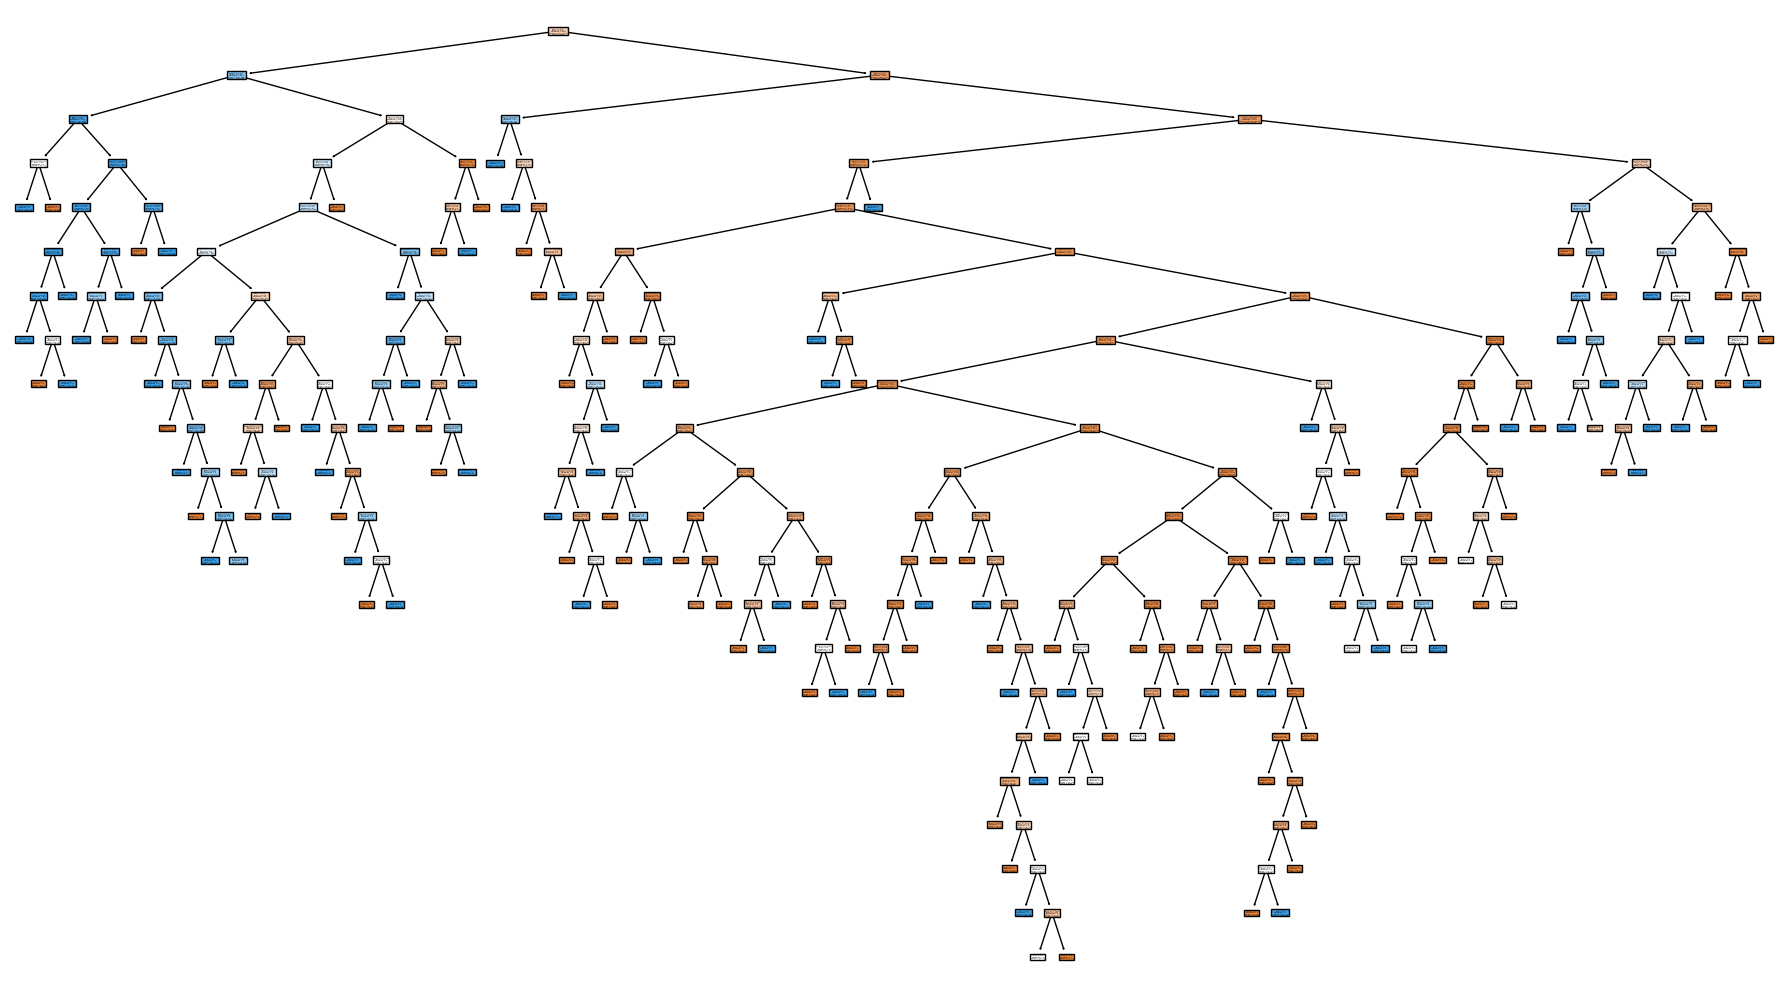

In [12]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(18,10))
plot_tree(
    model,
    feature_names=X.columns,
    class_names=["Died","Survived"],
    filled=True
)

plt.tight_layout()
plt.show()


In [13]:
# random forest

from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=201,      # odd
    oob_score=True,    # provides an unbiased, real-time estimate of how well a model will perform on unseen data
    max_depth=4
)

rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)

print("OOB score:",rf.oob_score_)
print("testing accuracy:", accuracy_score(y_test,y_pred))

OOB score: 0.8202247191011236
testing accuracy: 0.8134328358208955


In [14]:
# Bagging classifier - it reduces a machine learning model's variance and prevents overfitting by training 
                       # multiple versions of the same algorithm on different subsets of data

from sklearn.ensemble import BaggingClassifier

base_model = DecisionTreeClassifier()

bagging = BaggingClassifier(
    base_model,
    n_estimators=201
)

bagging.fit(X_train, y_train)
y_pred = bagging.predict(X_test)
print("accuracy_score:",accuracy_score(y_test,y_pred))

accuracy_score: 0.7611940298507462


In [15]:
# Bagging classifier

from sklearn.ensemble import BaggingClassifier
from sklearn.linear_model import LogisticRegression

base_model = LogisticRegression(max_iter=1000)

bagging = BaggingClassifier(
    base_model,
    n_estimators=201
)

bagging.fit(X_train, y_train)
y_pred = bagging.predict(X_test)
print("accuracy_score:",accuracy_score(y_test,y_pred))

accuracy_score: 0.7947761194029851
